# LeetCode #74: Search a 2D Matrix

https://leetcode.com/problems/search-a-2d-matrix/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (nested loops)** | $O(m \times n)$ | $O(1)$ |
| **Optimal: Binary Search on Flattened Index ★** | $O(\log(m \times n))$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (nested loops)
Check every cell row by row. Correct but $O(m \times n)$ — ignores both the row-sorted and column-sorted guarantees.

### Optimal: Binary Search on Flattened Index ★
Treat the $m \times n$ matrix as a single sorted array of length $m \times n$. Map a virtual index $\text{mid}$ to row $= \text{mid} / n$, col $= \text{mid} \% n$ and binary search exactly as on a 1D array. One pass, $O(\log(m \times n))$.

**Constraints:**
* m == matrix.length, n == matrix[i].length
* 1 <= m, n <= 100
* -10^4 <= matrix[i][j] <= 10^4
* Each row is sorted in non-decreasing order
* The first integer of each row is greater than the last integer of the previous row


## Solutions

### C#

In [ ]:
public bool SearchMatrix(int[][] matrix, int target) {
    int m = matrix.Length, n = matrix[0].Length;
    int lo = 0, hi = m * n - 1;
    while (lo <= hi) {
        int mid = lo + (hi - lo) / 2;
        // Map flat index to 2D position
        int val = matrix[mid / n][mid % n];
        if (val == target) return true;
        if (val < target) lo = mid + 1;
        else hi = mid - 1;
    }
    return false;
}


### Python

In [ ]:
def searchMatrix(self, matrix: list[list[int]], target: int) -> bool:
    m, n = len(matrix), len(matrix[0])
    lo, hi = 0, m * n - 1
    while lo <= hi:
        mid = lo + (hi - lo) // 2
        # Map flat index to 2D position
        val = matrix[mid // n][mid % n]
        if val == target:
            return True
        if val < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return False


### Go

In [ ]:
func searchMatrix(matrix [][]int, target int) bool {
    m, n := len(matrix), len(matrix[0])
    lo, hi := 0, m*n-1
    for lo <= hi {
        mid := lo + (hi-lo)/2
        // Map flat index to 2D position
        val := matrix[mid/n][mid%n]
        if val == target {
            return true
        }
        if val < target {
            lo = mid + 1
        } else {
            hi = mid - 1
        }
    }
    return false
}


### Rust

In [ ]:
pub fn search_matrix(matrix: Vec<Vec<i32>>, target: i32) -> bool {
    let m = matrix.len() as i32;
    let n = matrix[0].len() as i32;
    let (mut lo, mut hi) = (0i32, m * n - 1);
    while lo <= hi {
        let mid = lo + (hi - lo) / 2;
        // Map flat index to 2D position
        let val = matrix[(mid / n) as usize][(mid % n) as usize];
        if val == target { return true; }
        if val < target { lo = mid + 1; } else { hi = mid - 1; }
    }
    false
}


## Example Scenarios

**1. Common Case**
**Input:** matrix = [[1,3,5,7],[10,11,16,20],[23,30,34,60]], target = 3
Treat as 12-element sorted array. lo=0,hi=11. mid=5 → row=1,col=1 → 11 > 3 → hi=4. mid=2 → row=0,col=2 → 5 > 3 → hi=1. mid=0 → 1 < 3 → lo=1. mid=1 → row=0,col=1 → 3 = target → return true.

**2. Slightly Complex**
**Input:** matrix = [[1,3,5,7],[10,11,16,20],[23,30,34,60]], target = 13
13 falls between row 1 and row 2 values but is not present. Binary search converges with lo > hi, returning false after $\lceil \log_2 12 \rceil = 4$ iterations.

**3. Edge Case: Time Factor**
**Input:** 100×100 matrix, target = last element (10000th element)
Worst-case search depth $= \lceil \log_2(10^4) \rceil = 14$ iterations. Mid maps to row 99, col 99 repeatedly narrowing from the right.

**4. Edge Case: Space Factor**
**Input:** matrix = [[5]], target = 5
Single cell: lo=hi=0, mid=0, val=matrix[0][0]=5=target → return true in one step. $O(1)$ space: only lo, hi, mid, val allocated regardless of matrix size.

**5. Almost-Impossible but Plausible**
**Input:** 100×100 matrix with all values = -10^4, target = -10^4
First mid hits the target immediately (mid=4999, val=-10^4). Note: the constraint says rows are strictly increasing, so all-equal is technically invalid — but even with target at index 0 and n=100, the flat-index mapping (0/100=row 0, 0%100=col 0) works correctly at all boundary indices including 0 and $m*n-1$.


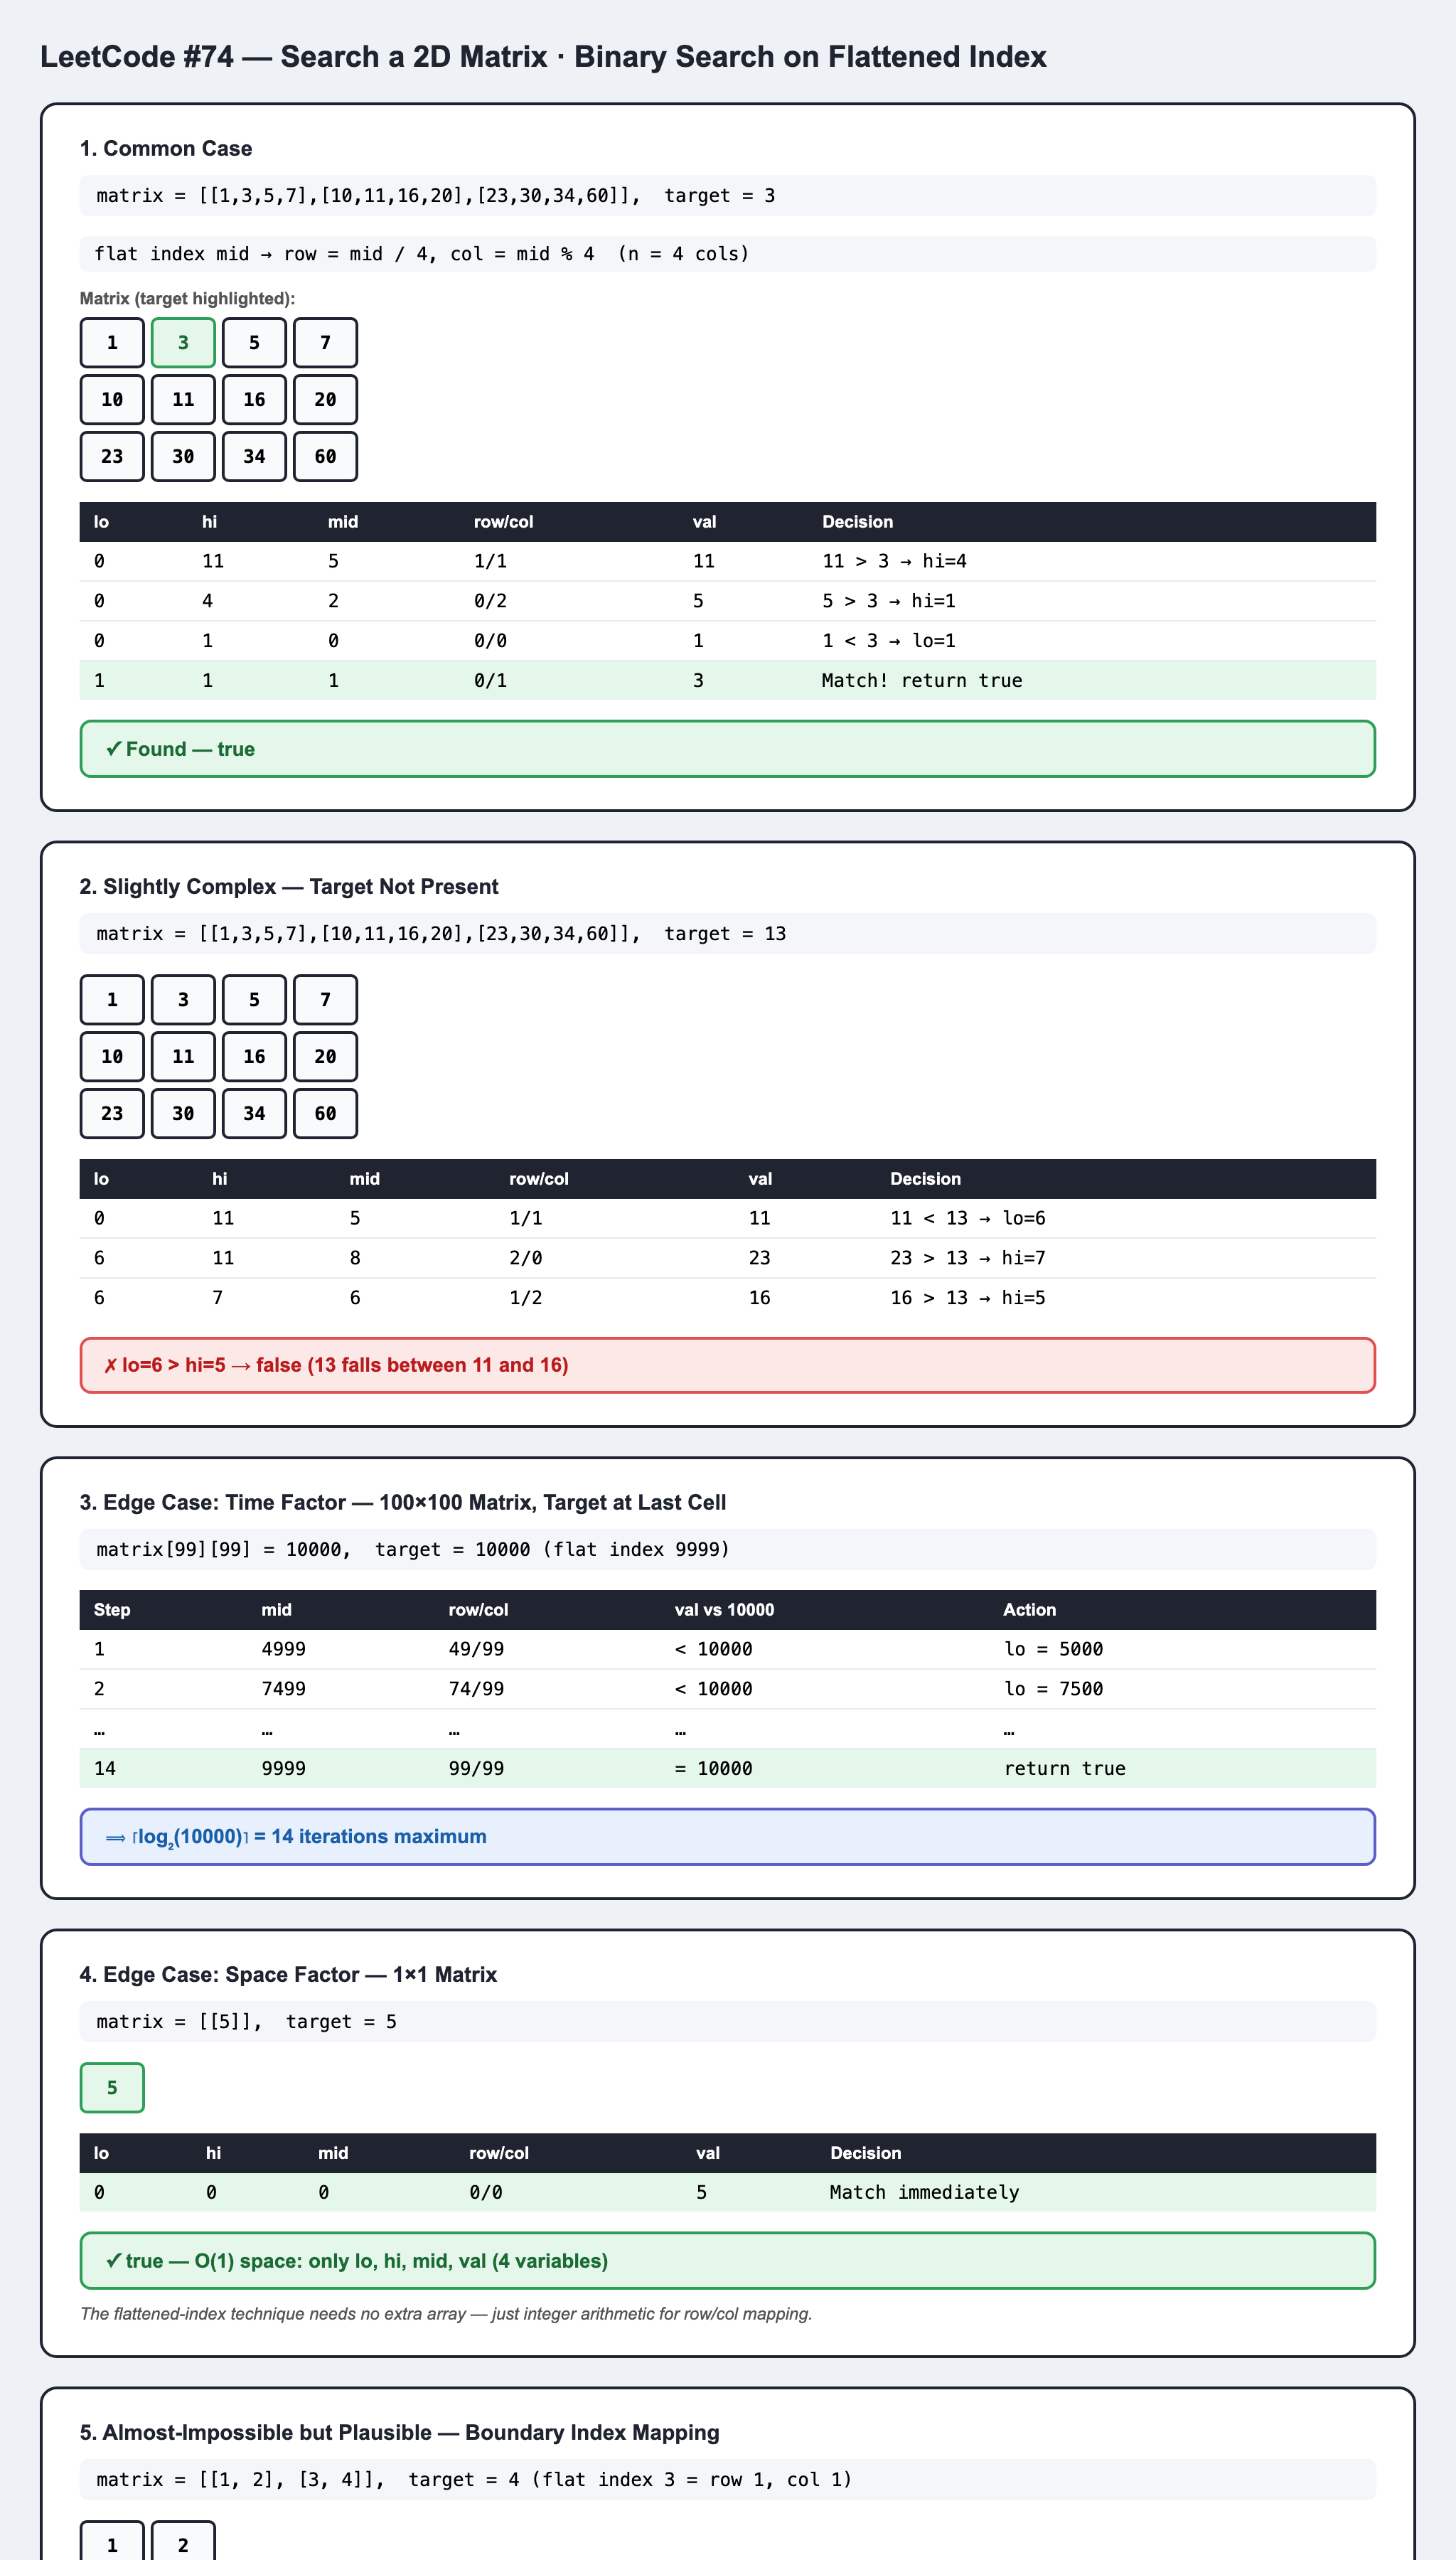